### Define some helper functions

In [20]:
from collections import defaultdict
import numpy as np
import torch

def evaluate_model(model, loader, eval_functions, mode="eval"):
    """Evaluate model on a data loader with given evaluation functions.
    Assumes metrics can be computed in batches and averaged."""
    orig_mode = model.training
    model.train(mode == "train")

    metrics = defaultdict(list)

    with torch.no_grad():
        for x, y in loader:
            preds = model(x)

            for name, fn in eval_functions.items():
                metrics[name].append(fn(preds, y).to(torch.float32).mean().item())

    model.train(orig_mode)

    return {name: np.mean(vals) for name, vals in metrics.items()}


def load_n(loader, n):
    i = 0
    while i < n:
        for x in loader:
            yield x
            i += 1
            if i == n:
                break

### Create MNIST dataloaders
We add a transform that turns each pixels into a single bit (0.-> False everyhting else -> True). This is standard procedure on MNIST. For other datasets, we would typically represent each pixel as multiple bits (binarization).

In [21]:
# turn inputs into binary values
from torchvision import datasets, transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader

batch_size = 128

transform = v2.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.).float())
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Build the model and loss function
We use a very simple convolutional model. This won't perform well, but it demonstrates a variety of `torchlogix`'s layers. Standard cross entropy for training and accurcay for training. Adam works well as optimizer, but notice the larger-than-usal learning rate!

In [22]:
from torchlogix.layers import LogicDense, LogicConv2d, GroupSum, OrPooling2d

model = torch.nn.Sequential(
    LogicConv2d(in_dim=28, channels=1, num_kernels=16, tree_depth=2, receptive_field_size=3),  # 
    OrPooling2d(kernel_size=2, stride=2, padding=0),  # Reduce dimensionality with pooling operation
    torch.nn.Flatten(),
    LogicDense(16*13*13, 4_000),
    LogicDense(4_000, 4_000),
    GroupSum(k=10, tau=8)  # classify into ten classes
)

loss_fn = torch.nn.CrossEntropyLoss()
eval_functions = {
    "loss": loss_fn,
    "acc": lambda preds, y: (preds.argmax(-1) == y).to(torch.float32).mean(),
}
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

### Run the training loop
Standard training loop, but we evaluate the model in relaxed (`train`) and discrete (`eval`) mode. 

In [23]:
num_iterations = 1000
eval_freq = 100
running_train_loss, n = 0.0, 0
metrics_dict = {"step": [], "test_acc_discrete": [], "test_loss_discrete": [], "test_acc_relaxed": [], "test_loss_relaxed": [], "train_loss": []}
for i, (x, y) in enumerate(load_n(train_loader, num_iterations)):
    model.train()
    x = model(x)
    loss = loss_fn(x, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    n += y.size(0)
    running_train_loss += loss
    # Evaluation
    if (eval_freq > 0 and ((i + 1) % eval_freq == 0)):
        # Evaluate on validation set
        discrete_metrics = evaluate_model(
            model, test_loader, eval_functions, mode="eval"
        )
        relaxed_metrics = evaluate_model(
            model, test_loader, eval_functions, mode="train"
        )

        metrics = \
            {f"test_{k}_discrete": v for k, v in discrete_metrics.items()} | \
            {f"test_{k}_relaxed": v for k, v in relaxed_metrics.items()} | \
            {"train_loss": running_train_loss.cpu().detach().item() / n * len(test_loader)}

        for k, v in metrics.items():
            metrics_dict[k].append(v)
        metrics_dict["step"].append(i + 1)

        print(f"Iteration {i + 1:6d} | " +
                " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()]))

        running_train_loss, n = 0.0, 0

Iteration    100 | test_loss_discrete: 3.3813 | test_acc_discrete: 0.1027 | test_loss_relaxed: 0.7704 | test_acc_relaxed: 0.8109 | train_loss: 0.9539
Iteration    200 | test_loss_discrete: 1.3021 | test_acc_discrete: 0.5319 | test_loss_relaxed: 0.4602 | test_acc_relaxed: 0.8723 | train_loss: 0.3719
Iteration    300 | test_loss_discrete: 0.7660 | test_acc_discrete: 0.7295 | test_loss_relaxed: 0.3779 | test_acc_relaxed: 0.8905 | train_loss: 0.2690
Iteration    400 | test_loss_discrete: 0.5615 | test_acc_discrete: 0.8098 | test_loss_relaxed: 0.3367 | test_acc_relaxed: 0.9012 | train_loss: 0.2237
Iteration    500 | test_loss_discrete: 0.4912 | test_acc_discrete: 0.8400 | test_loss_relaxed: 0.3090 | test_acc_relaxed: 0.9121 | train_loss: 0.2062
Iteration    600 | test_loss_discrete: 0.4428 | test_acc_discrete: 0.8550 | test_loss_relaxed: 0.2928 | test_acc_relaxed: 0.9142 | train_loss: 0.1937
Iteration    700 | test_loss_discrete: 0.4062 | test_acc_discrete: 0.8693 | test_loss_relaxed: 0.278

### Plot the results
Note that the two curves are both on the test set. The difference is relaxed vs discrete model.

Text(0.5, 0.01, 'Training Step')

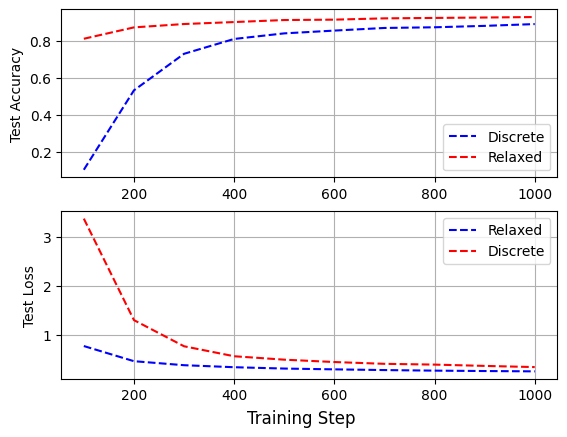

In [24]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1)
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_discrete"], "--", c="b", label="Discrete")
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_relaxed"], "--", c="r", label="Relaxed")
axs[0].set_ylabel("Test Accuracy")
axs[0].grid()
axs[0].legend()
axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_relaxed"], "--", c="b", label="Relaxed")
axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_discrete"], "--", c="r", label="Discrete")
axs[1].legend()
axs[1].set_ylabel("Test Loss")
axs[1].grid()
fig.supxlabel("Training Step")

### Build the boolean circuit
We first set the model into `export_mode`. This replaces the standard forward pass with purely boolean expressions. We can then trace it and turn it into `torchlogix`'s custom IR (`Circuit`), which is a fully unrolled computational graph whose nodes are individual logic ops or sum reductions. We simplify the graph with constant propagation, dead code elimination, etc., which significantly reduces the number of nodes.  

In [36]:
from torchlogix import Circuit
from torchlogix.utils import set_export_mode

set_export_mode(model)
circuit = Circuit.from_model(model, input_shape=(1, 28, 28))
print(f"Original circuit: {circuit}")
circuit.simplify()
print(f"Simplified circuit: {circuit}")

Original circuit: Circuit(
  n_inputs=784,
  input_shape=[1, 28, 28],
  logic_nodes=18483,
  sum_nodes=10,
  outputs=[19267, 19268, 19269, 19270, 19271, 19272, 19273, 19274, 19275, 19276],
  output_shape=[10]
)
Simplified circuit: Circuit(
  n_inputs=784,
  input_shape=[1, 28, 28],
  logic_nodes=6313,
  sum_nodes=10,
  outputs=[19267, 19268, 19269, 19270, 19271, 19272, 19273, 19274, 19275, 19276],
  output_shape=[10]
)


### Profile inference speed
First, we build a large test set that contains several batches. Then, we compile the circuit. This writes .C to a tmp file, compiles it, and loads the shared object with python bindings. Lastly, we assert that the outputs match.

In [26]:
from datetime import datetime

all_X = []
for x, y in load_n(test_loader, 64):  # Load 100 batches for profiling
    all_X.append(x)
all_X = torch.cat(all_X, dim=0).bool()
all_X_np = all_X.numpy()
print(f"all_X shape: {all_X.shape}")

t0 = datetime.now()
all_preds = model(all_X)
print("Time for original model:", datetime.now() - t0)

circuit.compile()
t0 = datetime.now()
all_preds_compiled = circuit(all_X_np, use_compiled=True)
print("Time for compiled model:", datetime.now() - t0)

assert torch.allclose(all_preds, torch.from_numpy(all_preds_compiled).float(), atol=1e-4), "Predictions do not match!"

all_X shape: torch.Size([8192, 1, 28, 28])
Time for original model: 0:00:01.218636
Time for compiled model: 0:00:00.023843


### Advanced compilation options
Inference can be sped-up even further w/ bit packing and higher compiler optimizations. On my macbook, the inference takes less than 5ms, wich amounts to a throughput of roughly 1.6M images per second.

In [ ]:
circuit.compile(pack_bits=32, opt_level=4)

t0 = datetime.now()
all_preds_compiled = circuit(all_X_np, use_compiled=True)
print("Time for compiled model without thresholding:", datetime.now() - t0)

assert torch.allclose(all_preds, torch.from_numpy(all_preds_compiled), atol=1e-4), "Predictions do not match!"

Time for compiled model without thresholding: 0:00:00.004370


### Generating HDL code
An instance of `Circuit` can also emit `verilog` code:

In [ ]:
s = circuit.get_verilog_code(inline_single_use=False)
print(s)

TypeError: Circuit.get_verilog_code() missing 1 required positional argument: 'inline_single_use'